# Turbulence Metric Surrogate

## What you will learn
How optimizing a proxy can select a design that fails nonlinear validation.

## Codes used
Pure Python cached design table; optional SPECTRAX-GK research path.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`09_proxy_vs_nonlinear.png` and `09_w7x_clamping_cartoon.png`.

## What this teaches

The object is a ranking test: when a fast turbulence proxy agrees or disagrees with validation.

## What this does not prove

It does not prove that the surrogate is reliable outside the cached teaching table.

## Literature anchor

Recent nonlinear turbulence optimization work shows why ranking by a cheap proxy is risky. Nonlinear heat-flux traces can be noisy in parameter space, and one practical response is staged optimization or stochastic gradient estimates that use only a small number of expensive evaluations.

Reading: Kim et al., *Journal of Plasma Physics* 90, 905900203 (2024), https://www.cambridge.org/core/journals/journal-of-plasma-physics/article/optimization-of-nonlinear-turbulence-in-stellarators/916FCC56452B5B166C14868F56D99AF5.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.turbulence_helpers import proxy_validation_table, clamping_cartoon
from sos2026.plotting import savefig, caption

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
table = proxy_validation_table()
table

,design,linear_proxy,quasilinear_proxy,nonlinear_validation
0,A_QS,0.22,0.31,0.50
1,B_low_ripple,0.18,0.28,0.37
2,C_easy_coils,0.42,0.46,0.54
3,D_turbulence_checked,0.30,0.23,0.21
4,E_balanced,0.26,0.25,0.27
5,F_aggressive,0.14,0.34,0.62


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

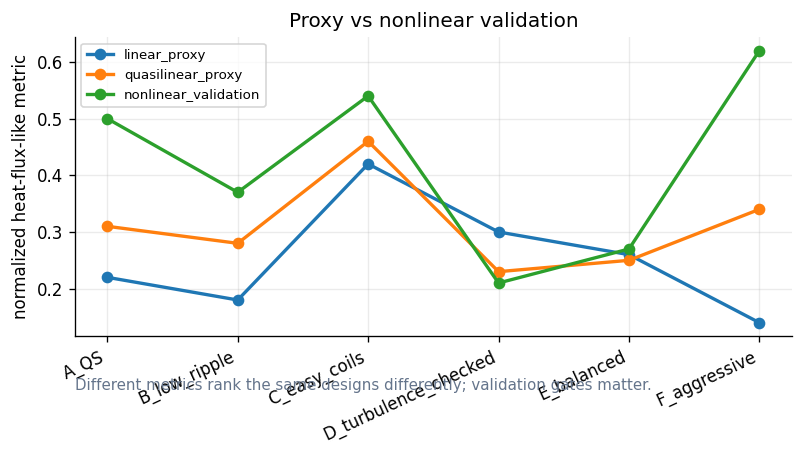

In [7]:
fig, ax = plt.subplots(figsize=(6.8, 3.9))
x = np.arange(len(table))
for col in ["linear_proxy", "quasilinear_proxy", "nonlinear_validation"]:
    ax.plot(x, table[col], marker="o", lw=2, label=col)
ax.set_xticks(x, table["design"], rotation=25, ha="right")
ax.set_ylabel("normalized heat-flux-like metric")
ax.set_title("Proxy vs nonlinear validation")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "Different metrics rank the same designs differently; validation gates matter.")
savefig(fig, "09_proxy_vs_nonlinear.png")
plt.show()

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

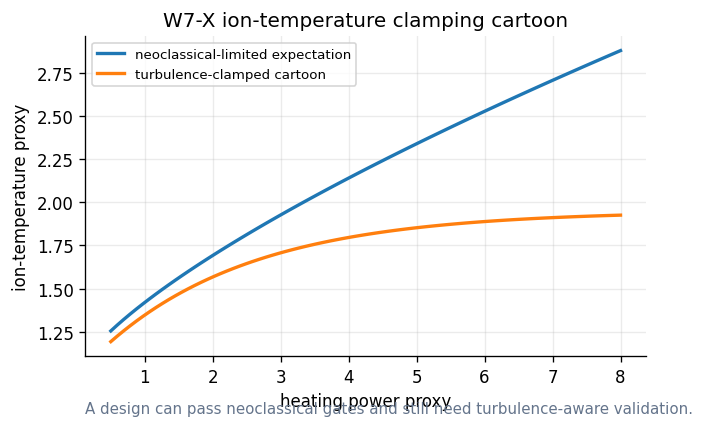

In [8]:
power, neo, turb = clamping_cartoon()
fig, ax = plt.subplots(figsize=(6.0, 3.7))
ax.plot(power, neo, lw=2, label="neoclassical-limited expectation")
ax.plot(power, turb, lw=2, label="turbulence-clamped cartoon")
ax.set_xlabel("heating power proxy")
ax.set_ylabel("ion-temperature proxy")
ax.set_title("W7-X ion-temperature clamping cartoon")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "A design can pass neoclassical gates and still need turbulence-aware validation.")
savefig(fig, "09_w7x_clamping_cartoon.png")
plt.show()

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
print("Best by linear proxy:", table.loc[table.linear_proxy.idxmin(), "design"])
print("Best by nonlinear validation:", table.loc[table.nonlinear_validation.idxmin(), "design"])
table.assign(linear_rank=table.linear_proxy.rank(), nonlinear_rank=table.nonlinear_validation.rank())

Best by linear proxy: F_aggressive
Best by nonlinear validation: D_turbulence_checked


,design,linear_proxy,quasilinear_proxy,nonlinear_validation,linear_rank,nonlinear_rank
0,A_QS,0.22,0.31,0.50,3.0,4.0
1,B_low_ripple,0.18,0.28,0.37,2.0,3.0
2,C_easy_coils,0.42,0.46,0.54,6.0,5.0
3,D_turbulence_checked,0.30,0.23,0.21,5.0,1.0
4,E_balanced,0.26,0.25,0.27,4.0,2.0
5,F_aggressive,0.14,0.34,0.62,1.0,6.0


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    print("Research path: replace nonlinear_validation with a validated nonlinear output column.")
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

,design,linear_proxy,nonlinear_validation,proxy_rank,nonlinear_rank
3,D_turbulence_checked,0.30,0.21,5.0,1.0
4,E_balanced,0.26,0.27,4.0,2.0
1,B_low_ripple,0.18,0.37,2.0,3.0
0,A_QS,0.22,0.50,3.0,4.0
2,C_easy_coils,0.42,0.54,6.0,5.0
5,F_aggressive,0.14,0.62,1.0,6.0


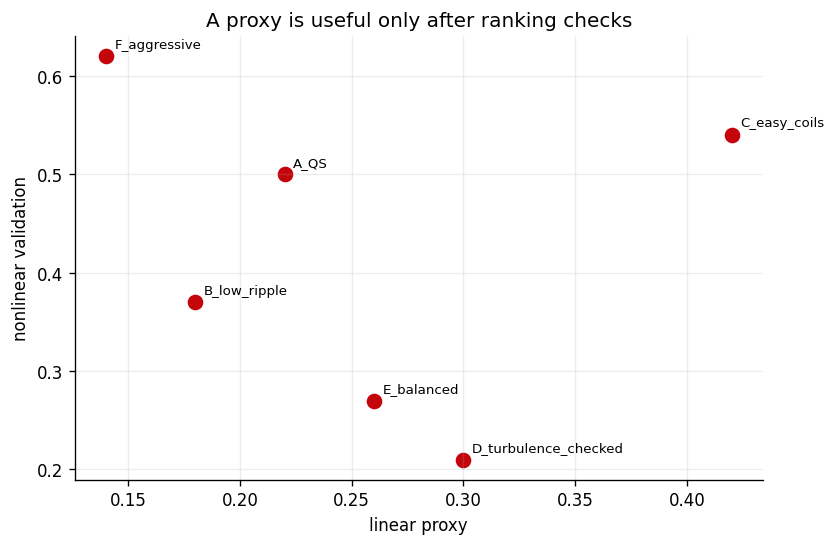

Caption: designs far from a monotonic trend are the cases that need higher-fidelity validation before optimization decisions.


In [13]:
from sos2026.turbulence_helpers import proxy_validation_table
df = proxy_validation_table()
ranked = df.assign(proxy_rank=df["linear_proxy"].rank(), nonlinear_rank=df["nonlinear_validation"].rank())
display(ranked[["design", "linear_proxy", "nonlinear_validation", "proxy_rank", "nonlinear_rank"]].sort_values("nonlinear_rank"))
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.scatter(ranked["linear_proxy"], ranked["nonlinear_validation"], s=70, color="#c5050c")
for _, row in ranked.iterrows():
    ax.annotate(row["design"], (row["linear_proxy"], row["nonlinear_validation"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("linear proxy")
ax.set_ylabel("nonlinear validation")
ax.set_title("A proxy is useful only after ranking checks")
ax.grid(alpha=0.22)
plt.show()
print("Caption: designs far from a monotonic trend are the cases that need higher-fidelity validation before optimization decisions.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.